# MLP on a Non-Linear Decision Boundary

Series position: Step 2 of the MLP → CNN series. Step 1 proved the mechanics (forward pass, backprop, loss convergence, optimizers) on a linear regression target. Step 2 keeps every one of those mechanics identical and changes exactly one variable: the target is now not linearly separable. This isolates a single question — does adding a hidden layer + non-linearity actually matter, or is it decorative? — and lets us answer it with a picture, not just a number.

### 0. Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

### 1. Synthetic Dataset — XOR Pattern

Step 1 used a linear generating function so the "correct" model was a single straight decision plane. Here we deliberately switch to an XOR-style pattern: class label flips depending on whether x0 and x1 have the same or different sign. This is the smallest, best-known example of a function that no single straight line can separate — which makes it the right controlled instrument for testing whether non-linearity is actually necessary.

In [2]:
def generate_data(n_samples=2000, noise_std=0.6):
    X = np.random.uniform(-4, 4, size=(n_samples, 2)).astype(np.float32)
    # Ground-truth rule: class 1 if x0 and x1 have different signs (XOR), else class 0
    y = (np.sign(X[:, 0]) != np.sign(X[:, 1])).astype(np.float32)
    X += np.random.normal(0, noise_std, size=X.shape).astype(np.float32)  # feature noise
    return torch.tensor(X), torch.tensor(y).view(-1, 1)

X, y = generate_data()

n_train = int(0.8 * len(X))
X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:], y[n_train:]

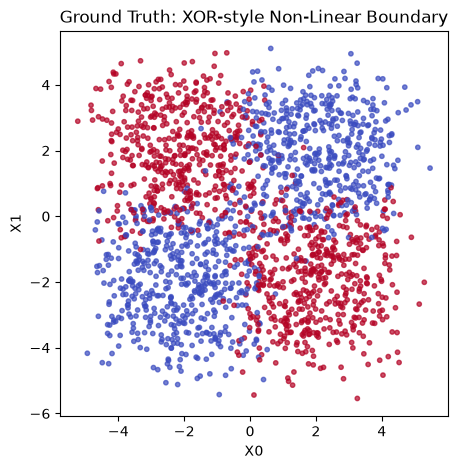

In [3]:
# Visualize the ground-truth pattern before training anything
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="coolwarm", s=10, alpha=0.7)
plt.title("Ground Truth: XOR-style Non-Linear Boundary")
plt.xlabel("X0"); plt.ylabel("X1")
plt.show()

### 2. Dataset & DataLoader

In [4]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

### 3. Model — MLP for Binary Classification

Same building blocks as Step 1 — Linear → ReLU → Linear — with two changes that matter for classification: a second hidden layer (one hidden layer can solve XOR in theory, but two makes the boundary easier to visualize cleanly) and a Sigmoid on the output to turn a raw score into a probability.

In [5]:
class MLP(nn.Module):
    def __init__(self, in_features=2, hidden_dim=16, out_features=1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_dim)   # W1: (16, 2)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)     # W2: (16, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim, out_features)   # W3: (1, 16)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.sigmoid(self.fc3(x))   # squashes output to a (0, 1) probability
        return x

model = MLP()

Forward propagation is unchanged in principle from Step 1: linear transform, non-linearity, repeat, until the final layer. The only new piece is the Sigmoid, which converts an unbounded score into something interpretable as "probability of class 1" — this is what makes the output usable for classification instead of regression.

### 4.Loss & Optimizer

In [6]:
criterion = nn.BCELoss()   # Binary Cross-Entropy — replaces MSE for classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

Loss changes from Step 1: Mean Squared Error measured distance between two numbers, which doesn't make sense for probabilities. Binary Cross-Entropy instead measures how confidently and correctly the model assigns probability mass to the true class — it penalizes confident wrong answers far more heavily than MSE would.

Loss convergence here is watched alongside accuracy, since a falling BCE loss doesn't always translate one-to-one into more correct classifications near decision boundaries — tracking both gives a fuller picture of what "learning" is actually doing.

Optimizer (Adam) plays the exact same role as in Step 1: given gradients from backprop, it decides the size and direction of each weight update.

### 5. Training Loop

In [7]:
def train(model, loader, criterion, optimizer, epochs=150):
    history = {"loss": [], "acc": []}
    for epoch in range(epochs):
        epoch_loss, correct, total = 0.0, 0, 0
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)                # forward pass
            loss = criterion(preds, yb)      # BCE loss
            loss.backward()                  # backpropagation
            optimizer.step()                 # weight update
            epoch_loss += loss.item() * xb.size(0)
            correct += ((preds > 0.5).float() == yb).sum().item()
            total += yb.size(0)
        history["loss"].append(epoch_loss / total)
        history["acc"].append(correct / total)
        if epoch % 15 == 0:
            print(f"Epoch {epoch:3d} | Loss: {history['loss'][-1]:.4f} | Acc: {history['acc'][-1]:.4f}")
    return history

history = train(model, train_loader, criterion, optimizer)

Epoch   0 | Loss: 0.3863 | Acc: 0.8519
Epoch  15 | Loss: 0.2399 | Acc: 0.8875
Epoch  30 | Loss: 0.2356 | Acc: 0.8862
Epoch  45 | Loss: 0.2357 | Acc: 0.8900
Epoch  60 | Loss: 0.2323 | Acc: 0.8869
Epoch  75 | Loss: 0.2288 | Acc: 0.8900
Epoch  90 | Loss: 0.2285 | Acc: 0.8875
Epoch 105 | Loss: 0.2285 | Acc: 0.8862
Epoch 120 | Loss: 0.2230 | Acc: 0.8962
Epoch 135 | Loss: 0.2229 | Acc: 0.8881


Backpropagation works identically to Step 1 — chain rule, layer by layer, backward from the loss. The one addition is that the gradient now has to pass through Sigmoid and BCELoss first, both covered in the deep-dive below.

### 6. Visualizing Convergence

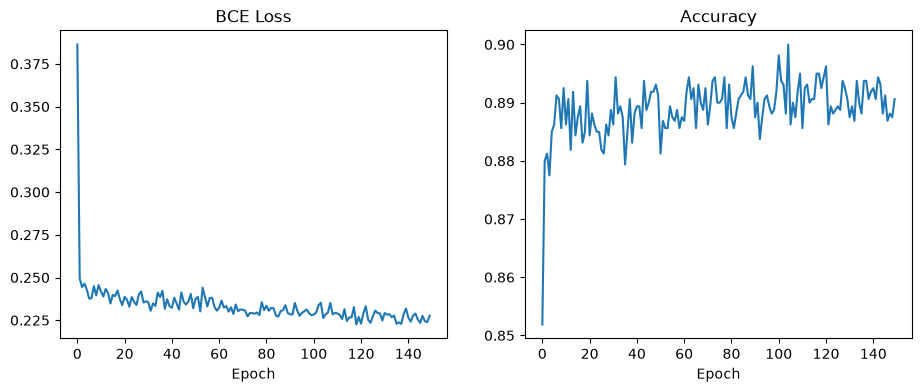

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["loss"]); ax[0].set_title("BCE Loss"); ax[0].set_xlabel("Epoch")
ax[1].plot(history["acc"]);  ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch")
plt.show()

### 7. The Payoff: Visualizing the Learned Decision Boundary

This is the step-2-specific sanity check, replacing Step 1's "compare learned weights to true coefficients." Since weights no longer map to a single interpretable line, we instead visualize the boundary the model has carved out of input space, directly against the known ground-truth XOR pattern.

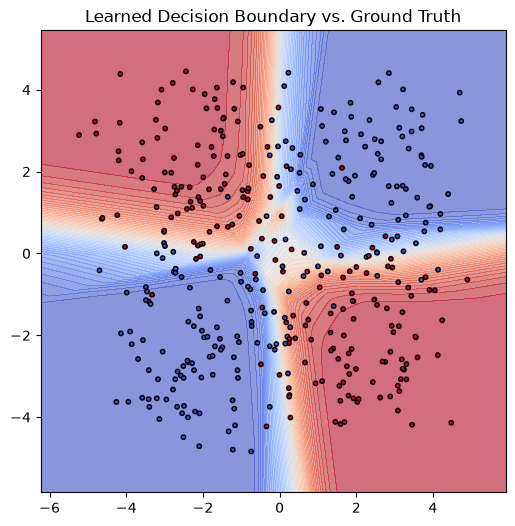

In [12]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        probs = model(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, probs, levels=50, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="coolwarm", edgecolor="k", s=10)
    plt.title("Learned Decision Boundary vs. Ground Truth")
    plt.show()

plot_decision_boundary(model, X_val, y_val)

### 8. Control Experiment — Removing the Non-Linearity

The most important cell in this notebook. Strip out both ReLU layers (i.e. stack three Linear layers with nothing between them) and retrain on the exact same data. Because a composition of linear functions is still linear, this collapses to a single linear classifier — and should visibly fail to separate the XOR pattern, plateauing near 50% accuracy (random guessing on a balanced binary set). This is the concrete, visual proof that the hidden layer's non-linearity is doing real work, not just adding parameters.

In [15]:
class MLP(nn.Module):
    def __init__(self, in_features=2, hidden_dim=16, out_features=1):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_dim)   # W1: (16, 2)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)     # W2: (16, 16)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim, out_features)   # W3: (1, 16)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x = self.relu1(self.fc1(x))
        # x = self.relu2(self.fc2(x))
        # replaced with below linear layers
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.sigmoid(self.fc3(x))   # squashes output to a (0, 1) probability
        return x

model = MLP()

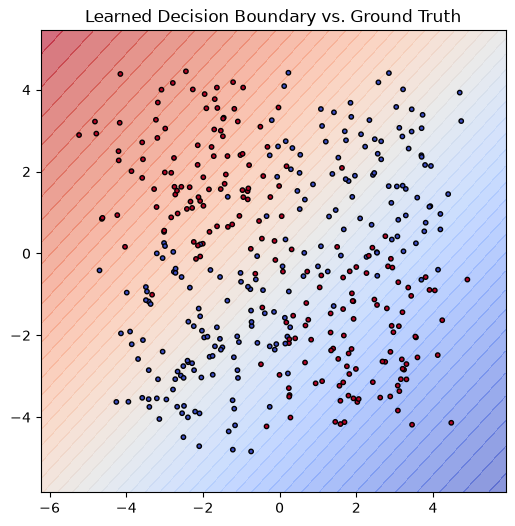

In [16]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        probs = model(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, probs, levels=50, cmap="coolwarm", alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="coolwarm", edgecolor="k", s=10)
    plt.title("Learned Decision Boundary vs. Ground Truth")
    plt.show()

plot_decision_boundary(model, X_val, y_val)